# Lab 6.03 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 3: Movies of 2006 and 2007

1. The file Movies_2006_2007 contains information on over 200
movies that were released during 2006 and 2007.

In [9]:
movies = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Movies_2006_2007.csv', delimiter = ";", encoding='cp1252')
# Show the first few records of the Data Frame
movies.head()

,Index,Movie,Distributor,Genre,7-day Gross,14-day Gross,Total US Gross,International Gross,US DVD Sales,Budget
0,1.0,The Texas Chainsaw Massacre: The Beginning,New Line,Horror,$22 707 121,$32 109 139,$39 517 763,$11 000 000,$15 909 367,$16 000 000
1,2.0,Year of the Dog,Paramount Vantage,Drama,$141 803,$318 598,$1 540 141,NaN,NaN,NaN
2,3.0,War,Lionsgate,Action,$12 839 402,NaN,$22 466 994,$18 200 000,$27 040 983,$25 000 000
3,4.0,Stomp the Yard,Sony Pictures,Drama,$28 263 594,$42 853 277,$61 356 221,$15 000 000,$33 166 898,$14 000 000
4,5.0,The Illusionist,Freestyle Releasing,Drama,NaN,NaN,$39 868 642,$44 407 533,$38 189 217,$16 500 000


2. Use cols_with_dollars to transform the amounts in dollars into floats.
For ease of use, change the values into 'million dollar' - values.  
E.g. $22 707 121	becomes 22.707121.  


In [10]:
cols_with_dollars = ['7-day Gross',	'14-day Gross',	'Total US Gross',	'International Gross',	'US DVD Sales',	'Budget']

In [11]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Index                211 non-null    float64
 1   Movie                211 non-null    object 
 2   Distributor          211 non-null    object 
 3   Genre                211 non-null    object 
 4   7-day Gross          156 non-null    object 
 5   14-day Gross         149 non-null    object 
 6   Total US Gross       211 non-null    object 
 7   International Gross  188 non-null    object 
 8   US DVD Sales         172 non-null    object 
 9   Budget               138 non-null    object 
dtypes: float64(1), object(9)
memory usage: 16.7+ KB


In [12]:
for item in cols_with_dollars:
  movies[item] = movies[item].str.replace(' ', '').str.replace('$', '').astype(float)

In [13]:
movies.head()

,Index,Movie,Distributor,Genre,7-day Gross,14-day Gross,Total US Gross,International Gross,US DVD Sales,Budget
0,1.0,The Texas Chainsaw Massacre: The Beginning,New Line,Horror,22707121.0,32109139.0,39517763.0,11000000.0,15909367.0,16000000.0
1,2.0,Year of the Dog,Paramount Vantage,Drama,141803.0,318598.0,1540141.0,NaN,NaN,NaN
2,3.0,War,Lionsgate,Action,12839402.0,NaN,22466994.0,18200000.0,27040983.0,25000000.0
3,4.0,Stomp the Yard,Sony Pictures,Drama,28263594.0,42853277.0,61356221.0,15000000.0,33166898.0,14000000.0
4,5.0,The Illusionist,Freestyle Releasing,Drama,NaN,NaN,39868642.0,44407533.0,38189217.0,16500000.0


In [14]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Index                211 non-null    float64
 1   Movie                211 non-null    object 
 2   Distributor          211 non-null    object 
 3   Genre                211 non-null    object 
 4   7-day Gross          156 non-null    float64
 5   14-day Gross         149 non-null    float64
 6   Total US Gross       211 non-null    float64
 7   International Gross  188 non-null    float64
 8   US DVD Sales         172 non-null    float64
 9   Budget               138 non-null    float64
dtypes: float64(7), object(3)
memory usage: 16.7+ KB


3. Create two scatterplots: one of Total US Gross (Y) versus
7-day Gross (X) and one of Total US Gross (Y)
versus 14-day Gross (X).

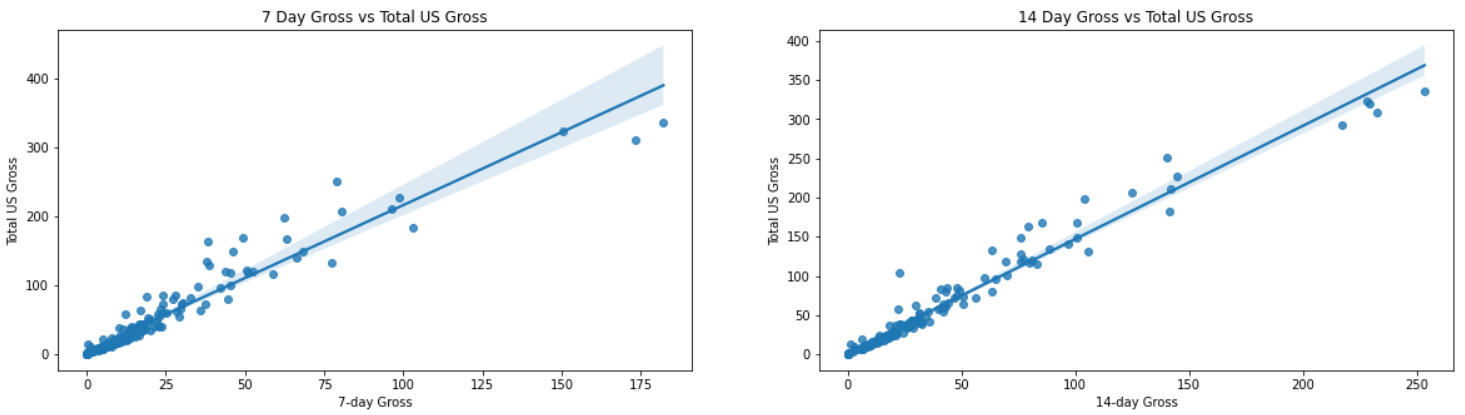

<Axes: xlabel='7-day Gross', ylabel='Total US Gross'>

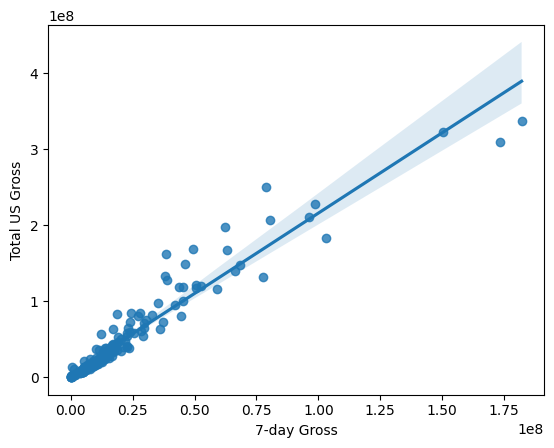

In [15]:
sns.regplot(data=movies, x='7-day Gross', y='Total US Gross')

<Axes: xlabel='14-day Gross', ylabel='Total US Gross'>

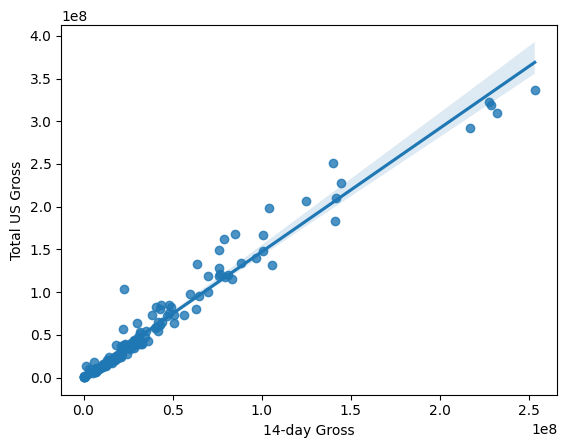

In [16]:
sns.regplot(data=movies, x='14-day Gross', y='Total US Gross')

4. What are the corresponding
values for $R$ and $R^2$?

R (7 Day Gross vs Total US Gross) = 0.959407544414305  
R² (7 Day Gross vs Total US Gross) = 0.9204628362790865  
R (14 Day Gross vs Total US Gross) = 0.9813238689021966  
R² (14) Day Gross vs Total US Gross) = 0.9629965356771755

In [18]:
R_7_day_gross = np.corrcoef(x=movies['7-day Gross'], y=movies['Total US Gross'])
R2_7_day_gross = R_7_day_gross**2

R_7_day_gross, R2_7_day_gross # NaN door bepaalde waarden die NaN zijn

(array([[nan, nan],
        [nan, nan]]),
 array([[nan, nan],
        [nan, nan]]))

In [46]:
# We maken nu 2 aparte sets

movies_7_day = movies[['7-day Gross',  'Total US Gross', 'Movie']].dropna()
movies_14_day = movies[['14-day Gross', 'Total US Gross',  'Movie']].dropna()

In [47]:
movies_7_day.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 0 to 209
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   7-day Gross     156 non-null    float64
 1   Total US Gross  156 non-null    float64
 2   Movie           156 non-null    object 
dtypes: float64(2), object(1)
memory usage: 4.9+ KB


In [48]:
movies_14_day.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 209
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   14-day Gross    149 non-null    float64
 1   Total US Gross  149 non-null    float64
 2   Movie           149 non-null    object 
dtypes: float64(2), object(1)
memory usage: 4.7+ KB


5. What are the equations of the linear regression lines in the previous part?  
What exactly does intercept and slope tell you about the movie business?

7 days gross: ŷ = 4.590921233818129 + 2.113464756610182 * x  
14 days gross: ŷ = 2.44900289255105 + 1.4464530702590803 * x

In [49]:
# 5.b
# betekenis b0_7d/b0_14d = intercept (7d) / (14d), met x 0 -> een film brengt meer dan 4/2.4 miljoen op als de film voor de rest niets opbrengt de eerste 7 dagen
# betekenis slope (7d/14d) = betekenis x = factor waarmee opbrengst van de eerste 7 / 14d mag vermenigvuldigen om totale opbrengst te kennen

# Dit is vreemd en komt door outliers (zie vraag box plot verder)

In [50]:
R_7_day_gross = np.corrcoef(x=movies_7_day['7-day Gross'], y=movies_7_day['Total US Gross'])[0][1]
R2_7_day_gross = R_7_day_gross**2

R_7_day_gross, R2_7_day_gross

(np.float64(0.959407544414305), np.float64(0.9204628362790865))

In [51]:
R_14_day_gross = np.corrcoef(x=movies_14_day['14-day Gross'], y=movies_14_day['Total US Gross'])[0][1]
R2_14_day_gross = R_14_day_gross**2

R_14_day_gross, R2_14_day_gross

(np.float64(0.9813238689021966), np.float64(0.9629965356771755))

In [52]:
# Conclusie voor beiden
# R > 0 -> stijgend
# R > 0.95 -> zeer sterk verband
# R**2 == 92, 96% hoge hoeveelheid variantie is verklaard door de regressie rechte

In [53]:
slope_7, intercept_7 = np.polyfit(x=movies_7_day['7-day Gross'], y=movies_7_day['Total US Gross'], deg=1)
print(f"y = {intercept_7} + x*{slope_7}")

y = 4590921.233818126 + x*2.1134647566101816


In [54]:
slope_14, intercept_14 = np.polyfit(x=movies_14_day['14-day Gross'], y=movies_14_day['Total US Gross'], deg=1)
print(f"y = {intercept_14} + x*{slope_14}")

y = 2449002.892551044 + x*1.4464530702590805


6. In the previous scatterplots you can see some ouliers at the right side. These are movies that did great
during their first week or two.
* 6.1 Make a boxplot to visualize the outliers for the first week or two.

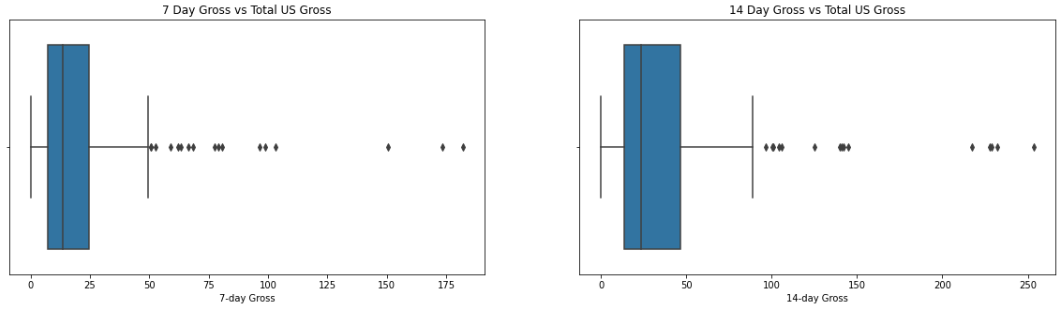

<Axes: xlabel='7-day Gross'>

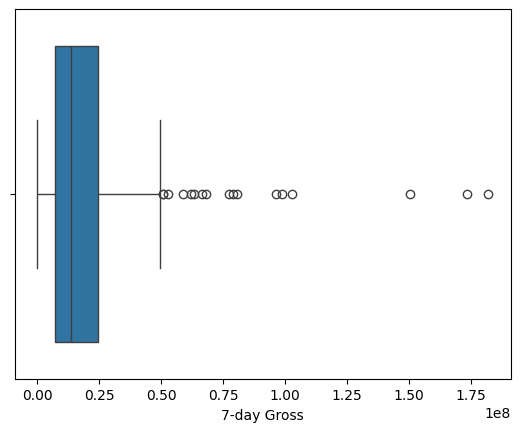

In [55]:
sns.boxplot(x=movies_7_day['7-day Gross'])

<Axes: xlabel='14-day Gross'>

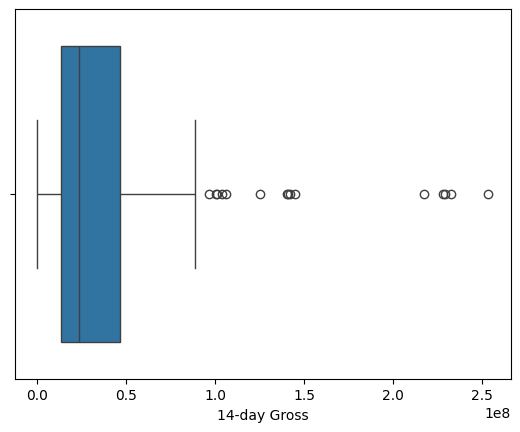

In [56]:
sns.boxplot(x=movies_14_day['14-day Gross'])

* 6.2 Calculate the upper limit values for the first week or two.

limit_7_days_gross is 50.376637875  
limit_14_days_gross is 96.2906745

In [57]:
#7 days
iqr_7_days = movies_7_day['7-day Gross'].quantile(0.75) - movies_7_day['7-day Gross'].quantile(0.25)

limit_7_days=movies_7_day['7-day Gross'].quantile(0.75) + 1.5*iqr_7_days
limit_7_days

np.float64(50376637.875)

In [58]:
#14 days
iqr_14_days = movies_14_day['14-day Gross'].quantile(0.75) - movies_14_day['14-day Gross'].quantile(0.25)

limit_14_days=movies_14_day['14-day Gross'].quantile(0.75) + 1.5*iqr_14_days
limit_14_days

np.float64(96290674.5)

* 6.3 What are the outliers for the first week or two?

A few movies for the first week:

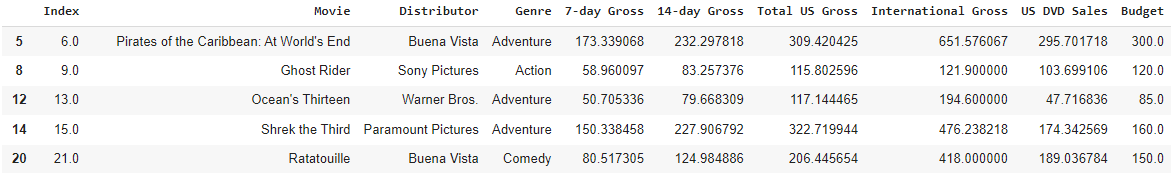

In [59]:
movies_7_day[movies_7_day['7-day Gross']>limit_7_days]

,7-day Gross,Total US Gross,Movie
5,173339068.0,309420425.0,Pirates of the Caribbean: At World's End
8,58960097.0,115802596.0,Ghost Rider
12,50705336.0,117144465.0,Ocean's Thirteen
14,150338458.0,322719944.0,Shrek the Third
20,80517305.0,206445654.0,Ratatouille
28,98673300.0,227471070.0,The Bourne Ultimatum
31,52547115.0,119725280.0,I Now Pronounce You Chuck and Larry
32,77453559.0,131921738.0,Fantastic Four: Rise of the Silver Surfer
35,63267784.0,167365000.0,Casino Royale
59,50572274.0,121463226.0,Superbad


In [60]:
movies_14_day[movies_14_day['14-day Gross']>limit_14_days]

,14-day Gross,Total US Gross,Movie
5,232297818.0,309420425.0,Pirates of the Caribbean: At World's End
14,227906792.0,322719944.0,Shrek the Third
20,124984886.0,206445654.0,Ratatouille
28,144820320.0,227471070.0,The Bourne Ultimatum
32,105800808.0,131921738.0,Fantastic Four: Rise of the Silver Surfer
35,100763154.0,167365000.0,Casino Royale
37,228950080.0,319246193.0,The Transformers
60,253357629.0,336530303.0,Spider-Man 3
104,141112342.0,183135014.0,The Simpsons Movie
118,140096754.0,250863268.0,Night at the Museum


* 6.4 Remove the outliers out of the dataset.

In [62]:
movies_7_day = movies_7_day[movies_7_day['7-day Gross']<limit_7_days]
movies_14_day = movies_14_day[movies_14_day['14-day Gross']<limit_14_days]

* 6.5 Give the new values for $R$ and $R^2$.


R (7 Day Gross vs Total US Gross)= 0.9324792650689281  
R² (7 Day Gross vs Total US Gross) = 0.8695175797834882

R (14 Day Gross vs Total US Gross)= 0.9584258717658031  
R² (14) Day Gross vs Total US Gross) = 0.9185801516700396

In [63]:
R_7_day_gross = np.corrcoef(x=movies_7_day['7-day Gross'], y=movies_7_day['Total US Gross'])[0][1]
R2_7_day_gross = R_7_day_gross**2

R_7_day_gross, R2_7_day_gross

(np.float64(0.932479265068929), np.float64(0.8695175797834899))

In [64]:
R_14_day_gross = np.corrcoef(x=movies_14_day['14-day Gross'], y=movies_14_day['Total US Gross'])[0][1]
R2_14_day_gross = R_14_day_gross**2

R_14_day_gross, R2_14_day_gross

(np.float64(0.9584258717658023), np.float64(0.9185801516700381))

In [ ]:
# Conclusie voor beiden
# R > 0 -> stijgend
# R > 0.93 -> zeer sterk verband
# R**2 == 87, 92% hoge hoeveelheid variantie is verklaard door de regressie rechte

* 6.6 Give the new values for the slope and the intercept of the regression lines. Do the outliers have a great effect?


7 days gross: ŷ = -5.073945979380596 + 2.7456809688135646 * x  
14 days gross: ŷ = -3.227354951096885 + 1.6529869503645318 * x

In [65]:
slope_7, intercept_7 = np.polyfit(x=movies_7_day['7-day Gross'], y=movies_7_day['Total US Gross'], deg=1)
print(f"y = {intercept_7} + x*{slope_7}")

y = -5073945.979380597 + x*2.7456809688135655


In [66]:
slope_14, intercept_14 = np.polyfit(x=movies_14_day['14-day Gross'], y=movies_14_day['Total US Gross'], deg=1)
print(f"y = {intercept_14} + x*{slope_14}")

y = -3227354.951096888 + x*1.652986950364532


In [ ]:
# Als opbrengst 0 is, is er nu een verlies van resp 5/3.2mln

<Axes: xlabel='7-day Gross'>

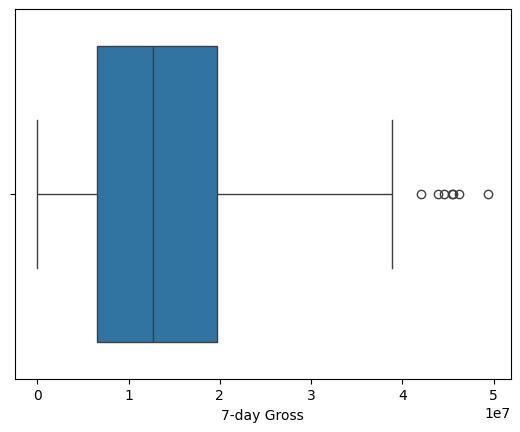

In [67]:
sns.boxplot(x=movies_7_day['7-day Gross']) #1e7 ipv 1e8

<Axes: xlabel='14-day Gross'>

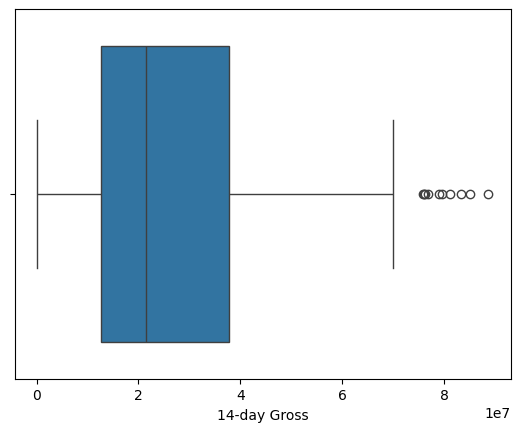

In [68]:
sns.boxplot(x=movies_14_day['14-day Gross']) #1e7 ipv 1e8